# Student Performance Analysis - Group Project
**DATA 581 - Data Visualization | Gonzaga University**  
**Group 2:** Harrison Christophersen & Kaili Golden  

**Theme:** Factors Affecting Academic Success  
**Dataset:** [Students Performance in Exams - Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

## Objectives
- Does test preparation affect scores?
- Which subjects are most strongly related?
- Are there score outliers worth flagging?
- Does parental education appear related to performance?

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

students = pd.read_csv("StudentsPerformance.csv")
students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Basic EDA

In [3]:
students.info()
print()
print(students.describe())
print()
print("Missing values:")
print(students.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000 

## Visualization 1 - Math Score Distribution

**Chart type:** Histogram  
**Question:** How are math scores distributed across all students, and are there any unusual values?

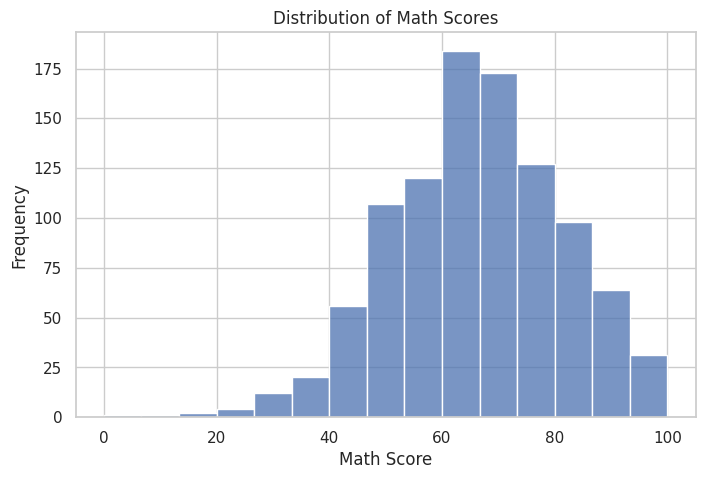

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=students, x='math score', bins=15)
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

**Why a histogram?** Scores are continuous, so a histogram lets us see the full distribution and spot outliers - particularly students scoring below 40, which is a concern worth flagging.

**Shape:** Roughly symmetric with a slight left tail. The low-score cluster (below 20) is small but notable.

## Visualization 2 - Test Preparation vs. Math Score

**Chart type:** Boxplot  
**Question:** Does completing the test preparation course relate to higher math scores, and does it reduce low outliers?

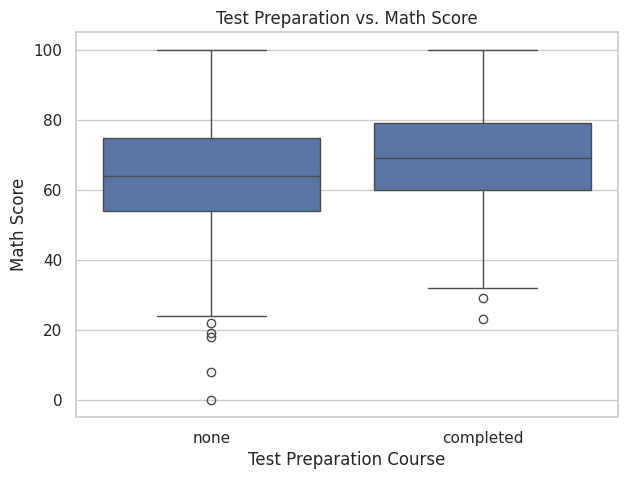

In [5]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=students, x='test preparation course', y='math score')
plt.title('Test Preparation vs. Math Score')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.show()

**Why a boxplot?** We are comparing a continuous variable (math score) across two categories. The boxplot shows median, spread, and outliers in one view.

**Findings:** Students who completed the course score higher at the median. Both groups have low-end outliers, but the completed group's overall distribution shifts noticeably upward.

## Visualization 3 - Subject Correlation Heatmap

**Chart type:** Heatmap  
**Question:** How strongly do math, reading, and writing scores correlate with each other?

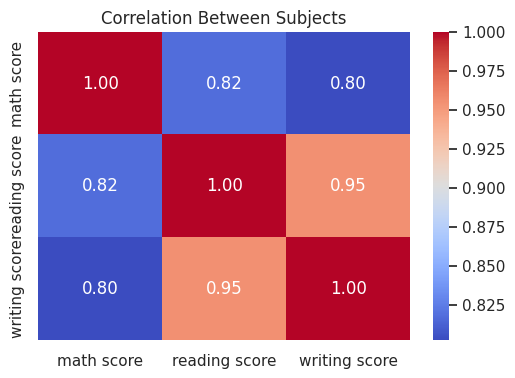

In [6]:
score_corr = students[['math score', 'reading score', 'writing score']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(score_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Subjects')
plt.show()

**Findings:** Reading and writing are most strongly correlated (r ≈ 0.95), which makes sense given their shared literacy foundation. Math correlates positively with both at around r ≈ 0.82, suggesting general academic ability carries across subjects.

## Visualization 4 - Parental Education vs. Math Score

**Chart type:** Bar chart  
**Question:** Does higher parental education relate to better student performance in math?

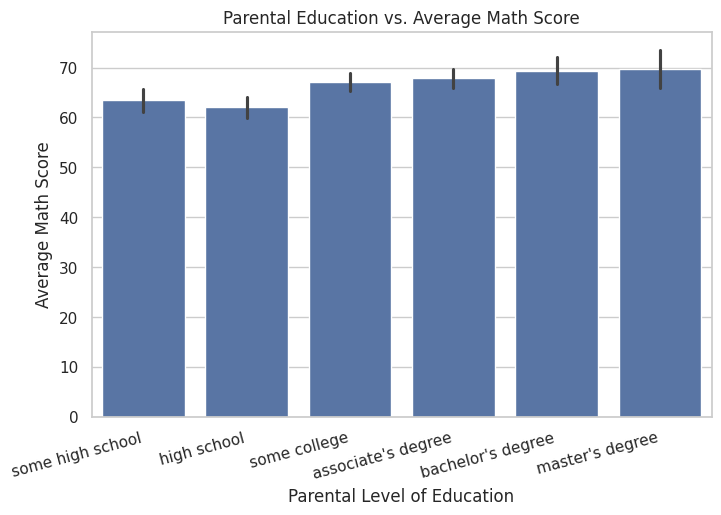

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=students,
    x='parental level of education',
    y='math score',
    order=['some high school', 'high school', 'some college',
           "associate's degree", "bachelor's degree", "master's degree"]
)
plt.title('Parental Education vs. Average Math Score')
plt.xticks(rotation=15, ha='right')
plt.ylabel('Average Math Score')
plt.xlabel('Parental Level of Education')
plt.show()

**Findings:** A consistent upward trend - students whose parents have higher education levels score higher on average. The gap between the lowest group (some high school) and highest (master's degree) is roughly 10-15 points. Some adjacent levels (e.g. high school vs. some high school) are similar, but the overall trend is clear.

## Visualization 5 - Average Score by Subject and Gender

**Chart type:** Grouped bar chart  
**Question:** Do gender differences vary by subject?

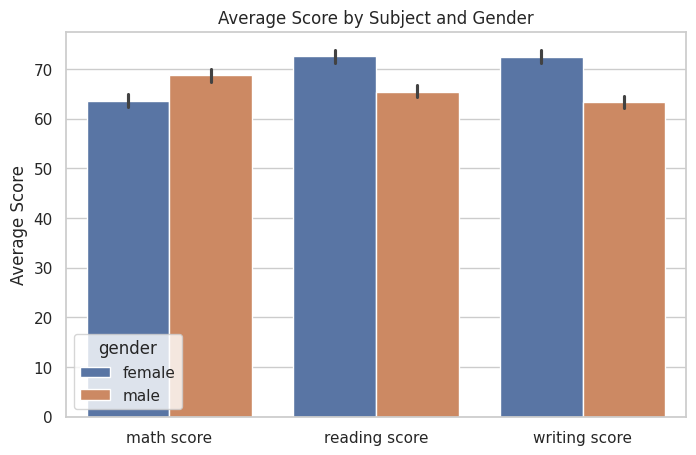

In [8]:
students_melted = students.melt(
    id_vars='gender',
    value_vars=['math score', 'reading score', 'writing score'],
    var_name='subject',
    value_name='score'
)

plt.figure(figsize=(8, 5))
sns.barplot(data=students_melted, x='subject', y='score', hue='gender')
plt.title('Average Score by Subject and Gender')
plt.ylabel('Average Score')
plt.xlabel('')
plt.show()

**Findings:** Male students outperform in math; female students outperform in reading and writing. The differences are consistent but not dramatic - gender explains some variation but is not the dominant factor in this dataset.

## Visualization 6 - Math vs. Reading Score by Test Preparation

**Chart type:** Scatter plot  
**Question:** Does test preparation produce visible clustering in the math/reading score space?

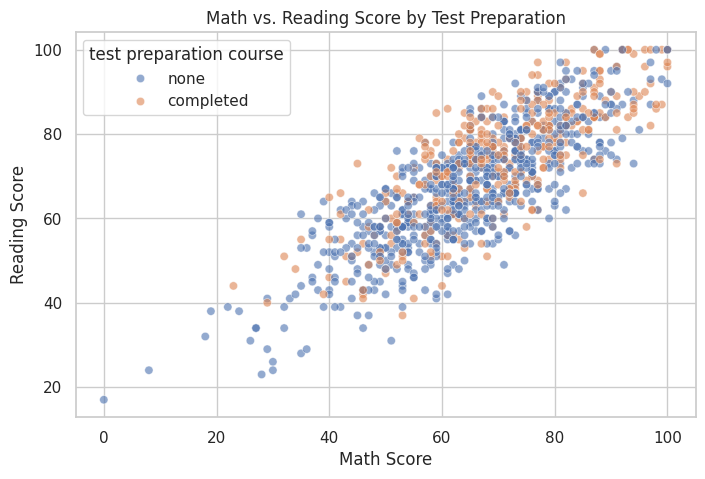

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=students,
    x='math score',
    y='reading score',
    hue='test preparation course',
    alpha=0.6
)
plt.title('Math vs. Reading Score by Test Preparation')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.show()

**Findings:** Students who completed the prep course tend to cluster in the upper-right region of the plot. There is overlap - some non-completers score well and some completers score low - but the general shift upward for completers is visible.

## Summary of Findings

| Factor | Finding |
|--------|---------|
| Test preparation | Consistently higher scores across all subjects; fewer low outliers |
| Subject correlation | Reading and writing highly correlated (r ≈ 0.95); math moderately correlated with both |
| Parental education | Positive relationship with math score; ~10-15 point gap across groups |
| Gender | Males higher in math; females higher in reading and writing; differences modest |
| Score distribution | Roughly normal; small cluster of very low math scores (<20) warrants attention |